<a href="https://www.kaggle.com/code/zahidmughal2343/walmart-sales-forecasting-with-4-ml-models?scriptVersionId=241393128" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart-sales-dataset-of-45stores/walmart-sales-dataset-of-45stores.csv


# Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
import joblib


# Load The Dataset

In [3]:
df = pd.read_csv("/kaggle/input/walmart-sales-dataset-of-45stores/walmart-sales-dataset-of-45stores.csv")

#  View First 5 Rows

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Check Shape of Dataset

In [5]:
df.shape

(6435, 8)

# Check Column Names

In [6]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

# Check for Missing Values

In [7]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# Data Types of Columns

In [8]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

# Summary Statistics

In [9]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


# Convert 'Date' to Datetime

In [10]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

# Total Sales by Store

In [11]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64

# Plot Total Sales by Store

<Axes: ylabel='Store'>

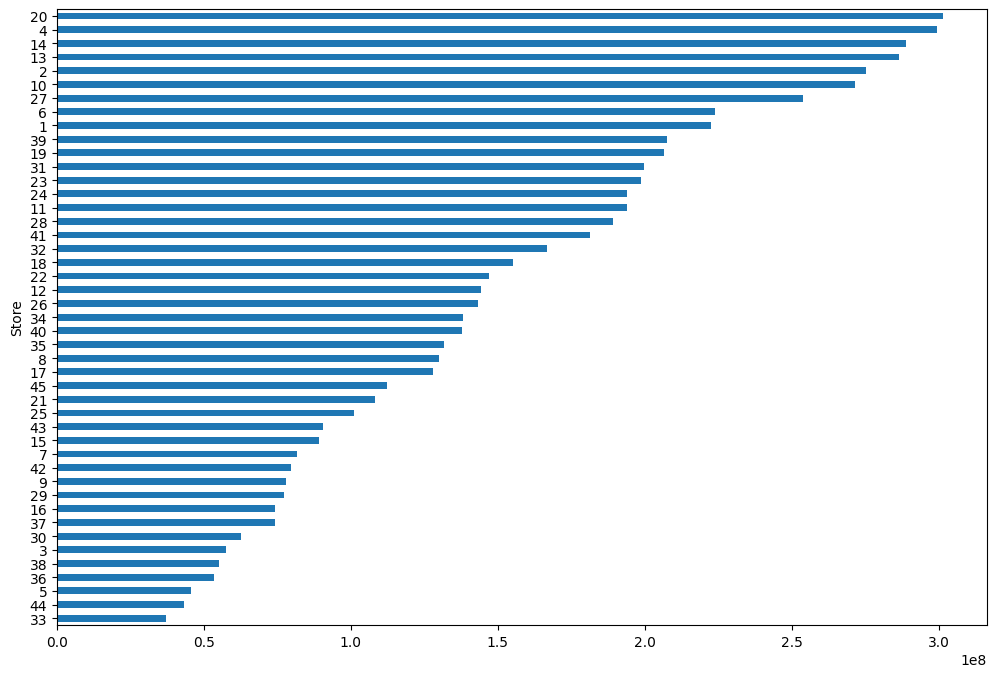

In [12]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values().plot(kind='barh', figsize=(12,8))

# Average Weekly Sales Over Time

<Axes: xlabel='Date'>

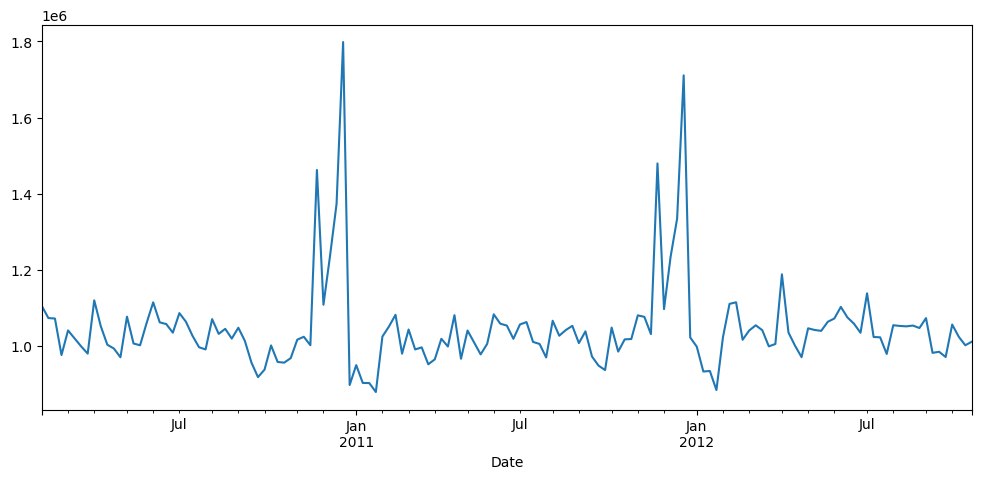

In [13]:
df.groupby('Date')['Weekly_Sales'].mean().plot(figsize=(12,5))

# Sales on Holidays vs Non-Holidays

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

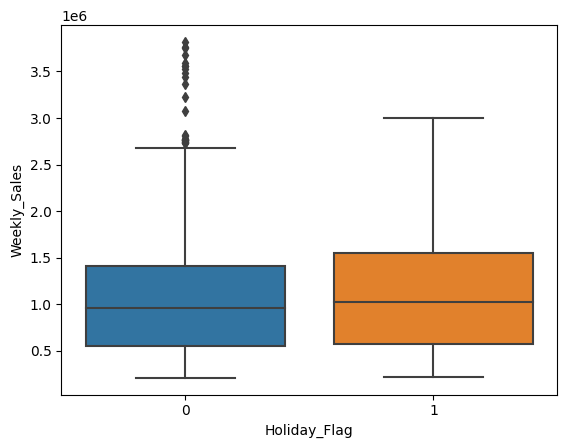

In [14]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

# Correlation Heatmap

<Axes: >

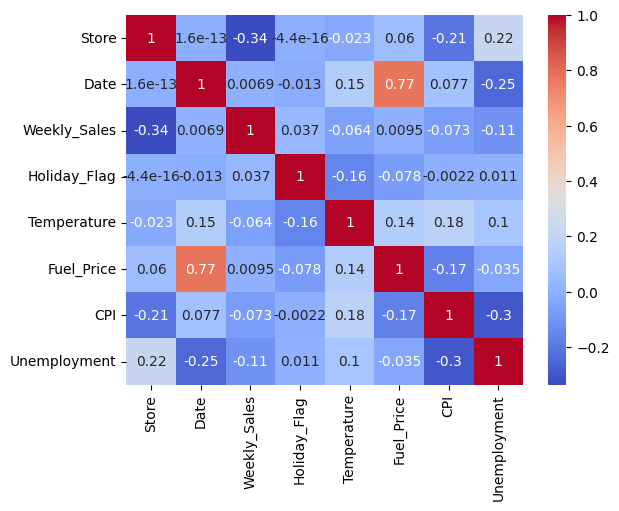

In [15]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Trend Analysis over Time

<Axes: xlabel='Month'>

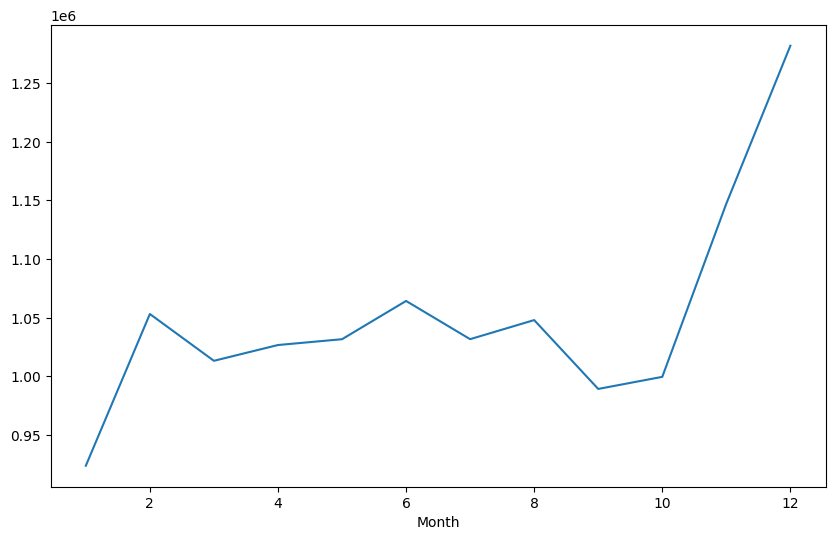

In [16]:
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(kind='line', figsize=(10,6))

# Feature Engineering

In [17]:
df['Year'] = df['Date'].dt.year
df['Weekday'] = df['Date'].dt.weekday
df = pd.get_dummies(df, columns=['Store', 'Holiday_Flag'])

# Train-Test Split

In [18]:
X = df.drop(columns=['Weekly_Sales', 'Date'])  # Features
y = df['Weekly_Sales']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Linear Regression MSE: {mean_squared_error(y_test, y_pred_lr)}")
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr)}")

Linear Regression MSE: 24144761015.267166
Linear Regression R2: 0.9250522461393088


# Random Forest Regressor

In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf)}")

Random Forest MSE: 21843298386.44896
Random Forest R2: 0.9321962163991585


# XGBoost

In [21]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"XGBoost MSE: {mean_squared_error(y_test, y_pred_xgb)}")
print(f"XGBoost R2: {r2_score(y_test, y_pred_xgb)}")

XGBoost MSE: 16000185454.357998
XGBoost R2: 0.9503338235404205


# LightGBM

In [22]:
lgb_model = lgb.LGBMRegressor()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print(f"LightGBM MSE: {mean_squared_error(y_test, y_pred_lgb)}")
print(f"LightGBM R2: {r2_score(y_test, y_pred_lgb)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1120
[LightGBM] [Info] Number of data points in the train set: 5148, number of used features: 53
[LightGBM] [Info] Start training from score 1044996.414472
LightGBM MSE: 12670611615.765718
LightGBM R2: 0.9606691538573378


# Compare the Models

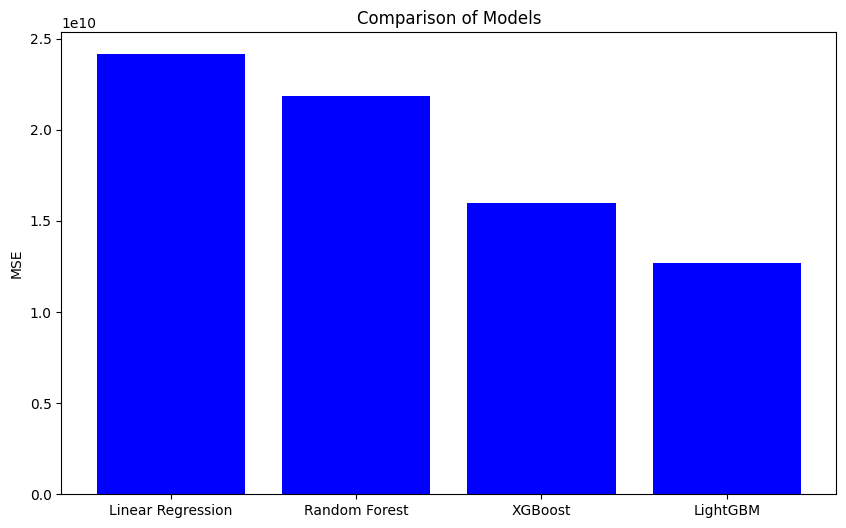

In [23]:
models = ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM']
mse_scores = [mean_squared_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_rf), mean_squared_error(y_test, y_pred_xgb), mean_squared_error(y_test, y_pred_lgb)]
r2_scores = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_xgb), r2_score(y_test, y_pred_lgb)]

# Plotting
plt.figure(figsize=(10,6))
plt.bar(models, mse_scores, color='blue', label='MSE')
plt.ylabel('MSE')
plt.title('Comparison of Models')
plt.show()